In [8]:
!nvidia-smi

Tue Sep  1 16:13:26 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA H100 80GB HBM3          On  |   00000000:4C:00.0 Off |                    0 |
| N/A   32C    P0            111W /  700W |     603MiB /  81559MiB |      0%      Default |
|                                         |                        |             Disabled |
+-----------------------------------------+-----

In [9]:
import os
import sys
import torch
from absl import app, flags
from tqdm import tqdm
import torchvision
import matplotlib.pyplot as plt
import torch

In [10]:
device=torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')

In [11]:
def image(image):
    return image.permute([1,2,0]).detach().cpu()
def kl_divergence(tensor1,tensor2,eps=1e-10):
    tensor1=torch.clamp(tensor1,min=eps)
    t2=torch.clamp(tensor2,min=eps)
    return torch.sum(tensor1*torch.log(tensor1/tensor2))
def plot_distribution(minimum_indices,k=2,grid=False,alpha=0.3):
    minimum_indices=minimum_indices if isinstance(minimum_indices,torch.Tensor) else torch.load(minimum_indices)
    values=minimum_indices[:,1]
    values = minimum_indices[:, 1].detach().cpu()
    num_elements = values.shape[0]
    x_axis = torch.arange(0, num_elements, 1)
    mean_val = torch.mean(values).item()
    top_k = torch.topk(values, k)
    top_values = top_k.values.tolist()
    top_indices = top_k.indices.tolist()

    plt.figure(figsize=(12, 6))
    plt.bar(x_axis, values, color="skyblue", alpha=alpha)
    if grid:
        plt.grid(True, axis='both', linestyle='--', alpha=0.7)
    plt.axhline(mean_val, color="red", linestyle=':', label=f'Mean: {mean_val:.4f}')

    for rank, (idx, val) in enumerate(zip(top_indices, top_values)):
        x_offset = num_elements * 0.04 if rank % 2 == 0 else -num_elements * 0.12
        y_offset = val * 0.95
        
        plt.annotate(
            f'#{rank+1} (Idx {idx}): {val:.4f}',
            xy=(idx, val),
            xytext=(idx + x_offset, y_offset),
            arrowprops=dict(arrowstyle="->", color="black", connectionstyle="arc3,rad=.2"),
            fontsize=9,
            weight='bold'
        )
    plt.xlabel("Index")
    plt.ylabel("LPIPS Distance")
    plt.title("LPIPS Distribution - Top 5 Maximum Values Highlighted")
    plt.legend()
    plt.tight_layout()
    plt.show()


## Analysis of FFHQ DATASET ##

In [12]:
original_images=torch.load('/home/saurabhg/scratch/FLOW_BASED_MODELS/LATENT_DATASET/flow_outputs_2/icfm/image_tensor/original_image_tensor.pt',map_location=device)

### ITERATION 1 ###

In [13]:
generated_images_iter1=torch.load('/home/saurabhg/scratch/FLOW_BASED_MODELS/LATENT_DATASET/flow_outputs_2/icfm/image_tensor/generated_images_1000_iteration1_python_inference_scipt.pt')
minimum_indices_iter1=torch.load('/home/saurabhg/scratch/FLOW_BASED_MODELS/LATENT_DATASET/flow_outputs_2/icfm/distances/iteration1/lpips_minimum_indices.pt')
frequency_distribution_iter1=torch.load('/home/saurabhg/scratch/FLOW_BASED_MODELS/LATENT_DATASET/flow_outputs_2/icfm/distances/iteration1/frequency_distribution.pt')

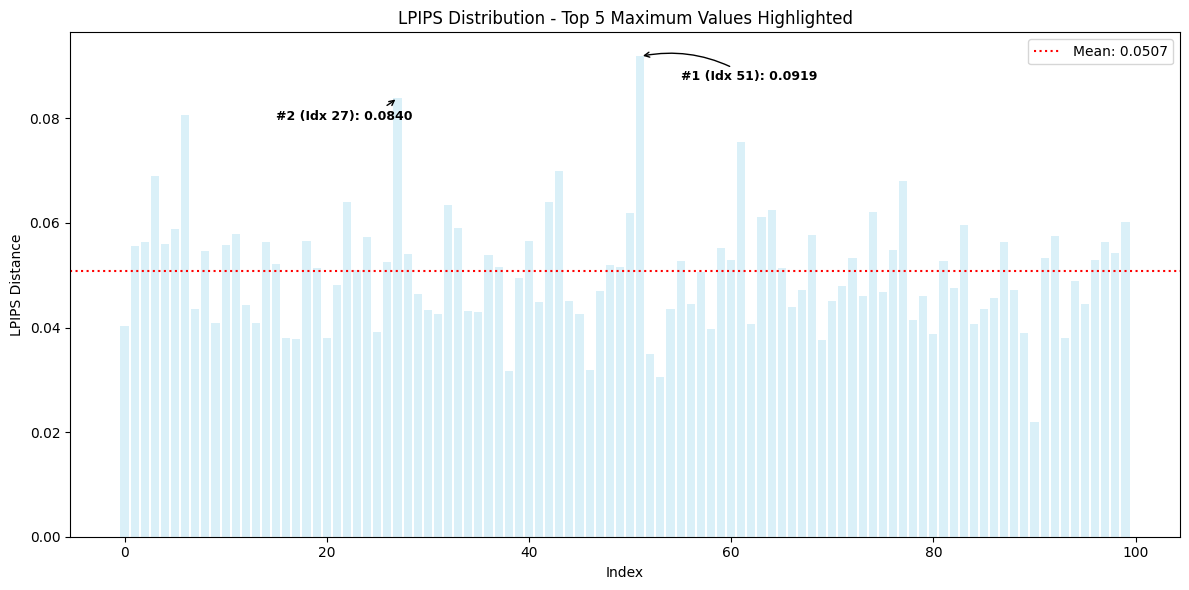

In [14]:
plot_distribution(minimum_indices_iter1)

In [15]:
frequency_distribution_iter1

tensor([[ 0., 16.],
        [ 1.,  8.],
        [ 2.,  6.],
        [ 3., 19.],
        [ 4., 13.],
        [ 5.,  2.],
        [ 6.,  5.],
        [ 7.,  7.],
        [ 8., 10.],
        [ 9.,  6.],
        [10.,  3.],
        [11.,  2.],
        [12.,  8.],
        [13., 19.],
        [14., 12.],
        [15.,  7.],
        [16.,  8.],
        [17., 12.],
        [18., 22.],
        [19.,  9.],
        [20.,  3.],
        [21.,  4.],
        [22., 10.],
        [23.,  9.],
        [24., 19.],
        [25.,  3.],
        [26.,  7.],
        [27.,  8.],
        [28.,  9.],
        [29.,  9.],
        [30.,  2.],
        [31., 28.],
        [32., 12.],
        [33., 10.],
        [34.,  8.],
        [35., 11.],
        [36.,  4.],
        [37., 10.],
        [38.,  3.],
        [39., 15.],
        [40.,  5.],
        [41., 10.],
        [42.,  5.],
        [43.,  4.],
        [44., 20.],
        [45.,  5.],
        [46.,  9.],
        [47.,  7.],
        [48., 18.],
        [49., 19.],


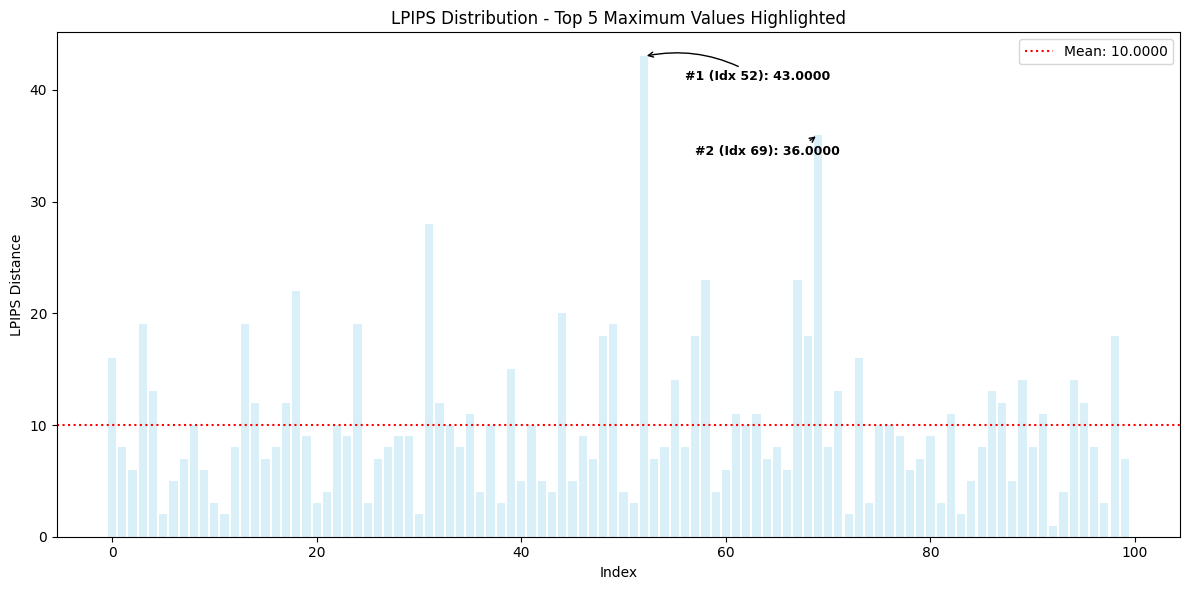

In [16]:
plot_distribution(frequency_distribution_iter1)

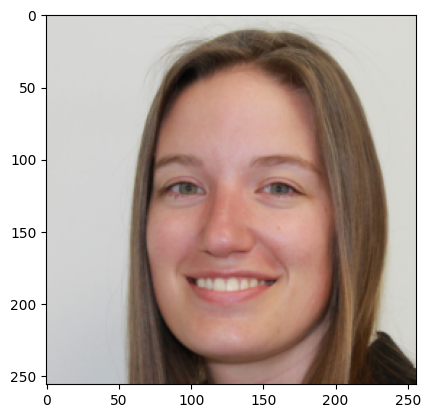

In [17]:
plt.imshow(image(original_images[52]))

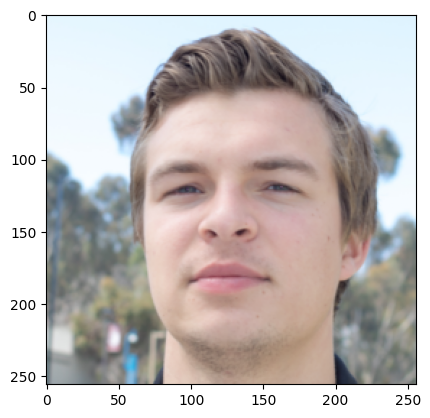

In [18]:
plt.imshow(image(original_images[92]))

tensor([[31., 28.],
        [69., 36.],
        [52., 43.]])


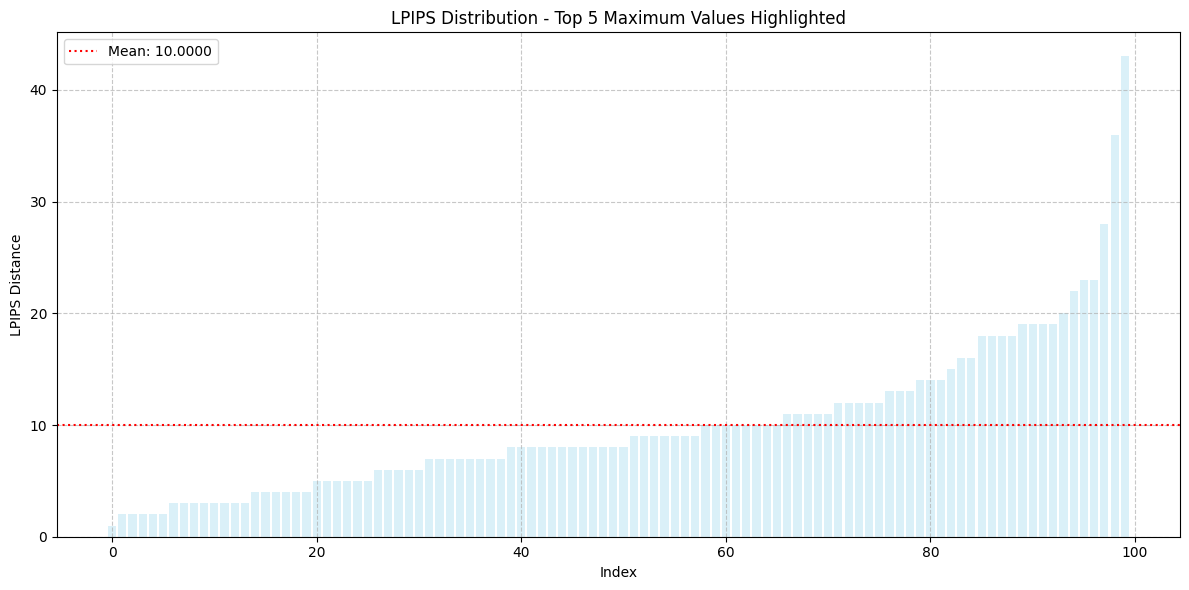

In [19]:
frequency_index_iter1=torch.argsort(frequency_distribution_iter1[:,1])
sorted_frequency_distribution_iter1=frequency_distribution_iter1[frequency_index_iter1]
print(sorted_frequency_distribution_iter1[-3:])
plot_distribution(sorted_frequency_distribution_iter1,k=0,grid=True)

In [20]:
sorted_frequency_distribution_iter1

tensor([[92.,  1.],
        [72.,  2.],
        [ 5.,  2.],
        [30.,  2.],
        [83.,  2.],
        [11.,  2.],
        [25.,  3.],
        [20.,  3.],
        [74.,  3.],
        [81.,  3.],
        [10.,  3.],
        [51.,  3.],
        [38.,  3.],
        [97.,  3.],
        [36.,  4.],
        [50.,  4.],
        [59.,  4.],
        [21.,  4.],
        [43.,  4.],
        [93.,  4.],
        [40.,  5.],
        [42.,  5.],
        [ 6.,  5.],
        [45.,  5.],
        [84.,  5.],
        [88.,  5.],
        [66.,  6.],
        [ 2.,  6.],
        [ 9.,  6.],
        [60.,  6.],
        [78.,  6.],
        [47.,  7.],
        [53.,  7.],
        [79.,  7.],
        [64.,  7.],
        [99.,  7.],
        [26.,  7.],
        [15.,  7.],
        [ 7.,  7.],
        [ 1.,  8.],
        [16.,  8.],
        [27.,  8.],
        [85.,  8.],
        [96.,  8.],
        [54.,  8.],
        [70.,  8.],
        [56.,  8.],
        [90.,  8.],
        [65.,  8.],
        [34.,  8.],


1 mode is dropped for generated batch of 1000 images

In [21]:
torch.sum(sorted_frequency_distribution_iter1[:,1][-27:])

tensor(507.)

27 modes make make up for the generation of more than 50% of images

In [22]:
generated_images_iter2=torch.load('/home/saurabhg/scratch/FLOW_BASED_MODELS/LATENT_DATASET/flow_outputs_2/icfm/image_tensor/generated_images_1000_iteration2_python_inference_scipt.pt')
minimum_indices_iter2=torch.load('/home/saurabhg/scratch/FLOW_BASED_MODELS/LATENT_DATASET/flow_outputs_2/icfm/distances/iteration2/lpips_minimum_indices.pt')
# minimum_indices_iter2=torch.load('/home/saurabhg/scratch/FLOW_BASED_MODELS/LATENT_DATASET/flow_outputs_2/icfm/distances/iteration2/lpips_minimum_indices.pt')
frequency_distribution_iter2=torch.load('/home/saurabhg/scratch/FLOW_BASED_MODELS/LATENT_DATASET/flow_outputs_2/icfm/distances/iteration2/frequency_distribution.pt')

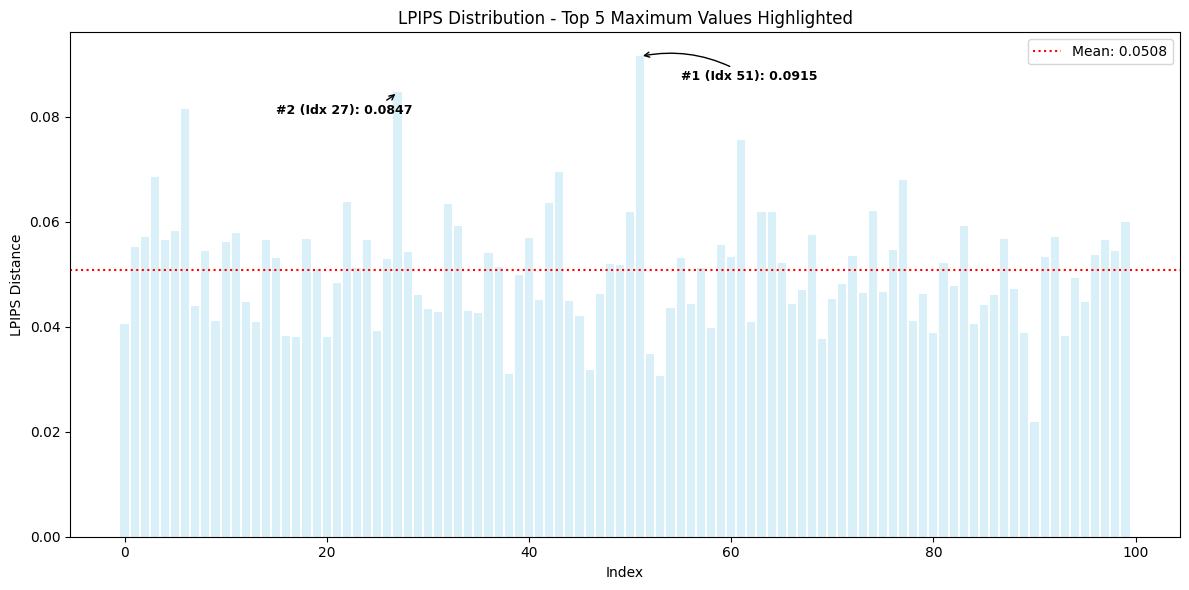

In [23]:
plot_distribution(minimum_indices_iter2)

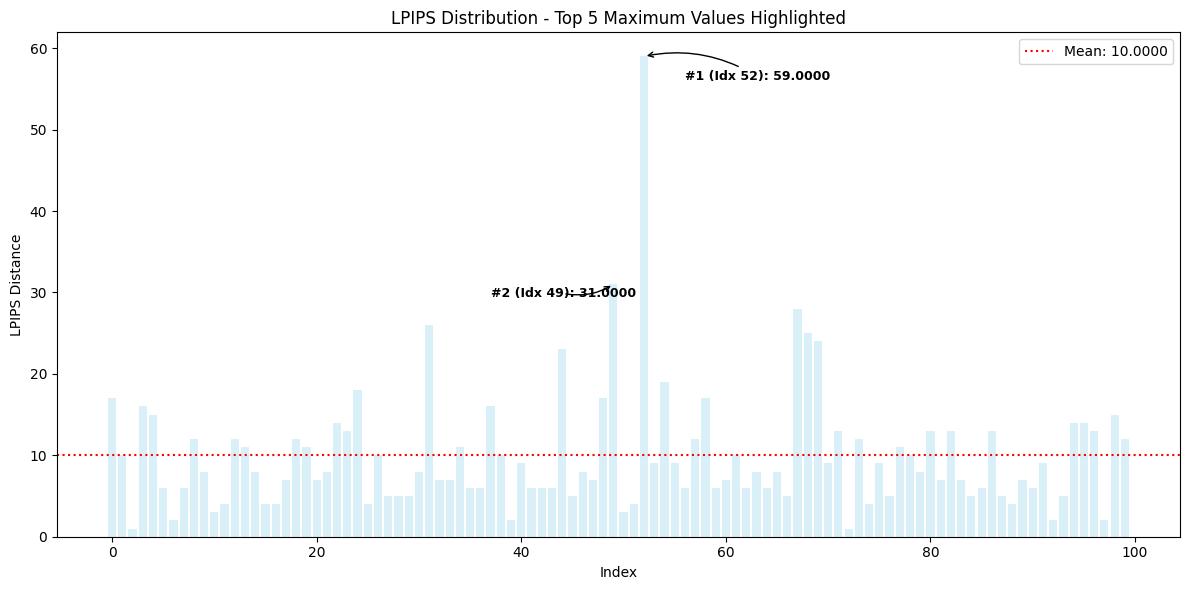

In [24]:
plot_distribution(frequency_distribution_iter2)

tensor([[67., 28.],
        [49., 31.],
        [52., 59.]])


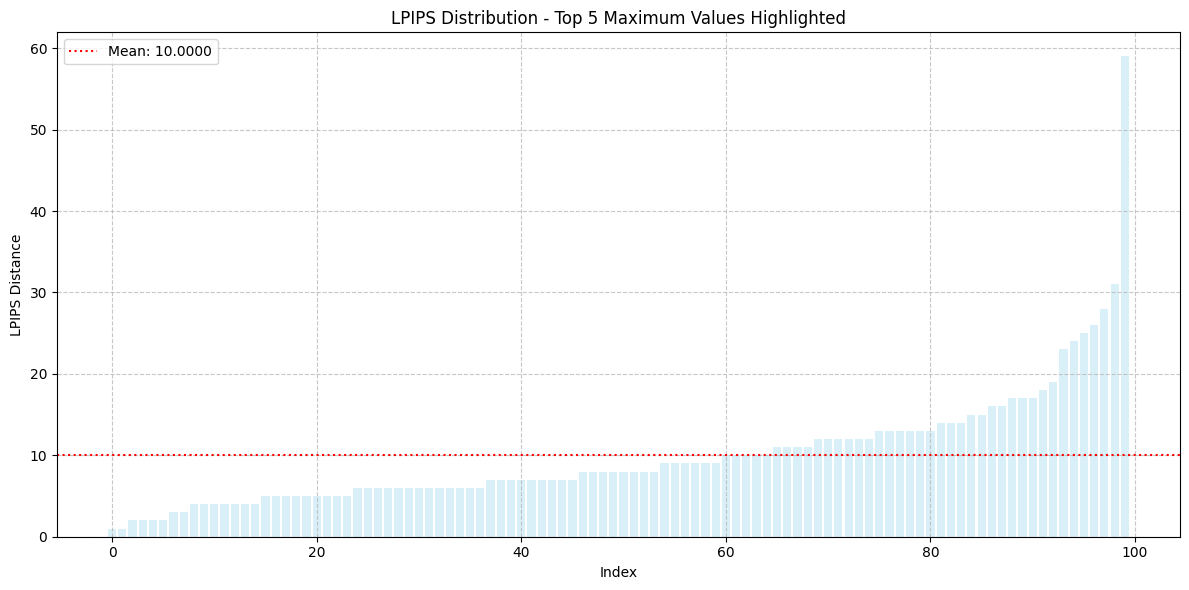

In [25]:
frequency_index_iter2=torch.argsort(frequency_distribution_iter2[:,1])
sorted_frequency_distribution_iter2=frequency_distribution_iter2[frequency_index_iter2]
print(sorted_frequency_distribution_iter2[-3:])
plot_distribution(sorted_frequency_distribution_iter2,k=0,grid=True)

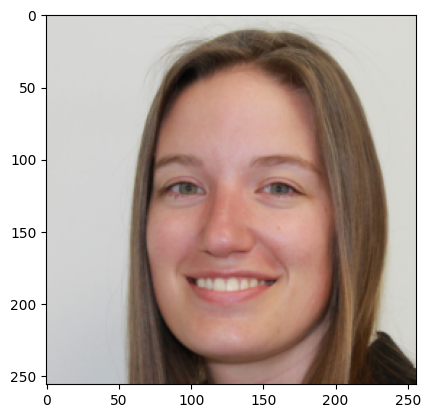

In [26]:
plt.imshow(image(original_images[52]))

In [27]:
sorted_frequency_distribution_iter2

tensor([[ 2.,  1.],
        [72.,  1.],
        [97.,  2.],
        [39.,  2.],
        [92.,  2.],
        [ 6.,  2.],
        [10.,  3.],
        [50.,  3.],
        [16.,  4.],
        [25.,  4.],
        [74.,  4.],
        [88.,  4.],
        [15.,  4.],
        [11.,  4.],
        [51.,  4.],
        [84.,  5.],
        [76.,  5.],
        [29.,  5.],
        [28.,  5.],
        [27.,  5.],
        [93.,  5.],
        [87.,  5.],
        [45.,  5.],
        [66.,  5.],
        [43.,  6.],
        [42.,  6.],
        [64.,  6.],
        [41.,  6.],
        [59.,  6.],
        [56.,  6.],
        [62.,  6.],
        [36.,  6.],
        [35.,  6.],
        [ 5.,  6.],
        [ 7.,  6.],
        [90.,  6.],
        [85.,  6.],
        [47.,  7.],
        [60.,  7.],
        [89.,  7.],
        [17.,  7.],
        [20.,  7.],
        [33.,  7.],
        [32.,  7.],
        [81.,  7.],
        [83.,  7.],
        [30.,  8.],
        [63.,  8.],
        [79.,  8.],
        [65.,  8.],


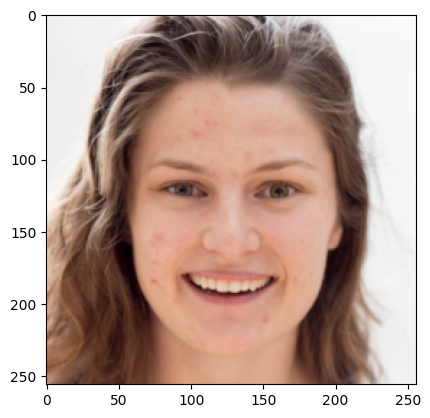

In [28]:
plt.imshow(image(original_images[2]))

In [29]:
torch.sum(sorted_frequency_distribution_iter2[:,1][-26:])

tensor(498.)

### Iteration 3 ###

In [30]:
generated_images_iter3=torch.load('/home/saurabhg/scratch/FLOW_BASED_MODELS/LATENT_DATASET/flow_outputs_2/icfm/image_tensor/generated_images_1000_iteration3_python_inference_scipt.pt')
minimum_indices_iter3=torch.load('/home/saurabhg/scratch/FLOW_BASED_MODELS/LATENT_DATASET/flow_outputs_2/icfm/distances/iteration3/lpips_minimum_indices.pt')
frequency_distribution_iter3=torch.load('/home/saurabhg/scratch/FLOW_BASED_MODELS/LATENT_DATASET/flow_outputs_2/icfm/distances/iteration3/frequency_distribution.pt')

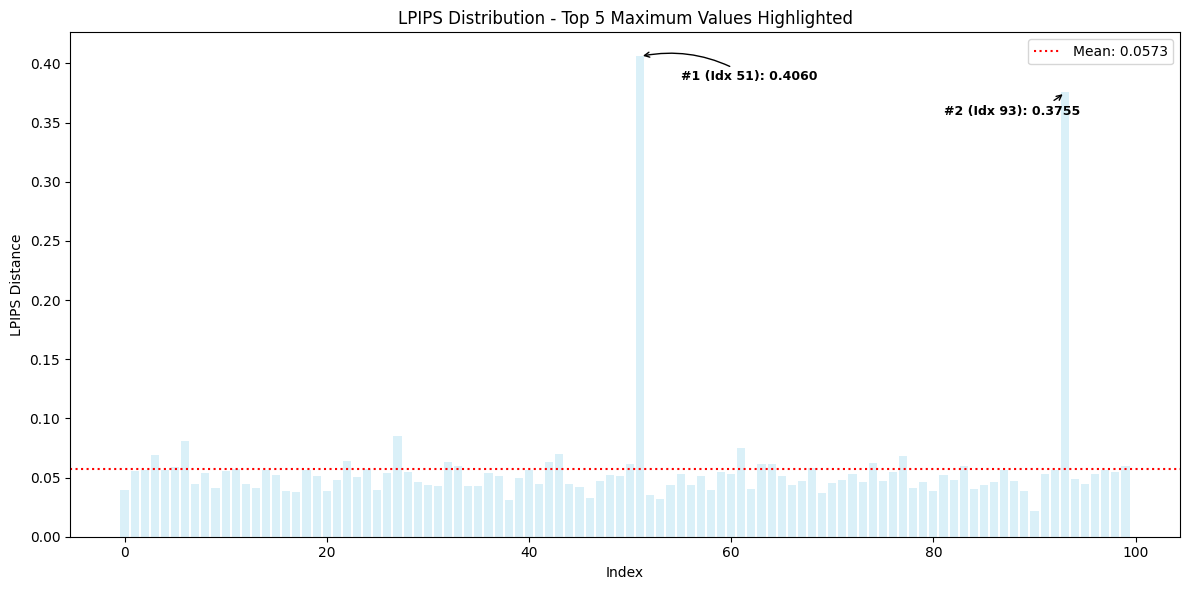

In [31]:
plot_distribution(minimum_indices_iter3)

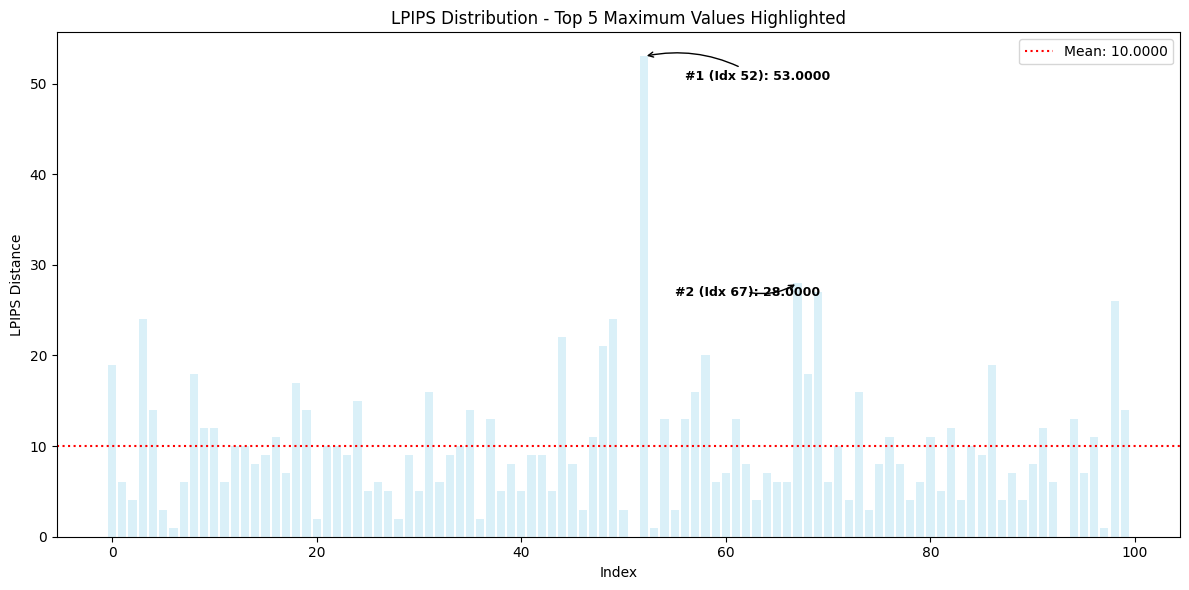

In [32]:
plot_distribution(frequency_distribution_iter3)

tensor([[69., 27.],
        [67., 28.],
        [52., 53.]])


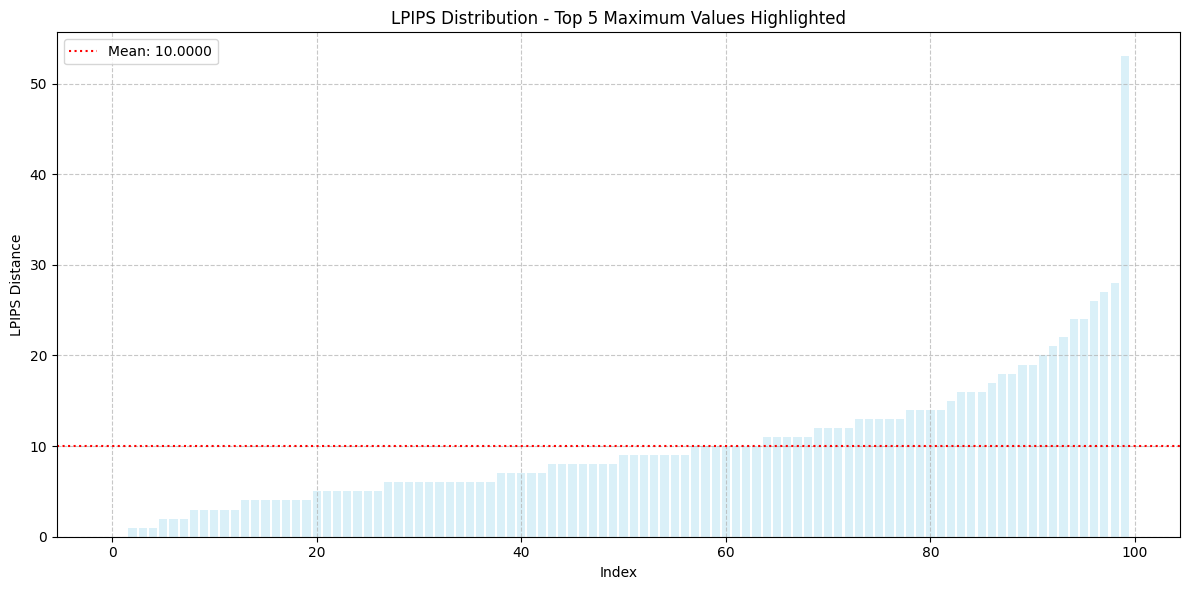

In [33]:
frequency_index_iter3=torch.argsort(frequency_distribution_iter3[:,1])
sorted_frequency_distribution_iter3=frequency_distribution_iter3[frequency_index_iter3]
print(sorted_frequency_distribution_iter3[-3:])
plot_distribution(sorted_frequency_distribution_iter3,k=0,grid=True)

In [34]:
sorted_frequency_distribution_iter3

tensor([[93.,  0.],
        [51.,  0.],
        [97.,  1.],
        [53.,  1.],
        [ 6.,  1.],
        [36.,  2.],
        [28.,  2.],
        [20.,  2.],
        [46.,  3.],
        [50.,  3.],
        [ 5.,  3.],
        [74.,  3.],
        [55.,  3.],
        [83.,  4.],
        [ 2.,  4.],
        [89.,  4.],
        [63.,  4.],
        [72.,  4.],
        [78.,  4.],
        [87.,  4.],
        [38.,  5.],
        [40.,  5.],
        [30.,  5.],
        [43.,  5.],
        [25.,  5.],
        [81.,  5.],
        [27.,  5.],
        [ 1.,  6.],
        [65.,  6.],
        [79.,  6.],
        [92.,  6.],
        [70.,  6.],
        [59.,  6.],
        [66.,  6.],
        [11.,  6.],
        [32.,  6.],
        [ 7.,  6.],
        [26.,  6.],
        [95.,  7.],
        [60.,  7.],
        [88.,  7.],
        [64.,  7.],
        [17.,  7.],
        [75.,  8.],
        [62.,  8.],
        [39.,  8.],
        [90.,  8.],
        [77.,  8.],
        [14.,  8.],
        [45.,  8.],


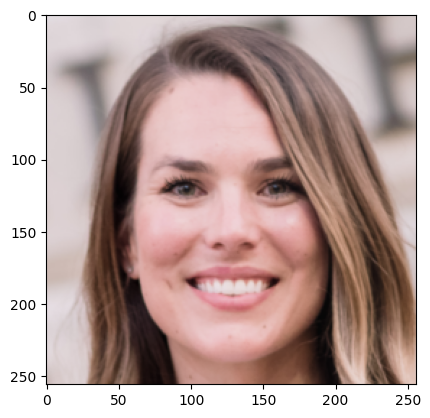

In [35]:
plt.imshow(image(original_images[93]))

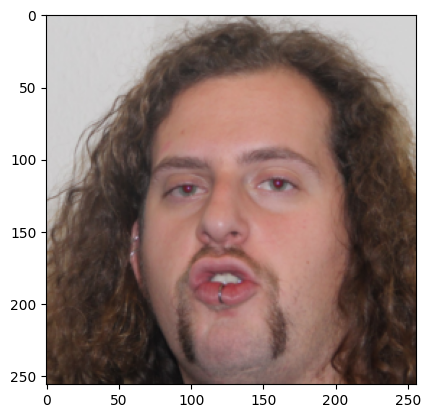

In [36]:
plt.imshow(image(original_images[51]))

In [37]:
torch.sum(sorted_frequency_distribution_iter3[:,1][-26:])

tensor(507.)

### Iteration 4 ###

In [38]:
generated_images_iter4=torch.load('/home/saurabhg/scratch/FLOW_BASED_MODELS/LATENT_DATASET/flow_outputs_2/icfm/image_tensor/generated_images_3000_iteration4_python_inference_scipt.pt')
minimum_indices_iter4=torch.load('/home/saurabhg/scratch/FLOW_BASED_MODELS/LATENT_DATASET/flow_outputs_2/icfm/distances/iteration4/lpips_minimum_indices.pt')
frequency_distribution_iter4=torch.load('/home/saurabhg/scratch/FLOW_BASED_MODELS/LATENT_DATASET/flow_outputs_2/icfm/distances/iteration4/frequency_distribution.pt')

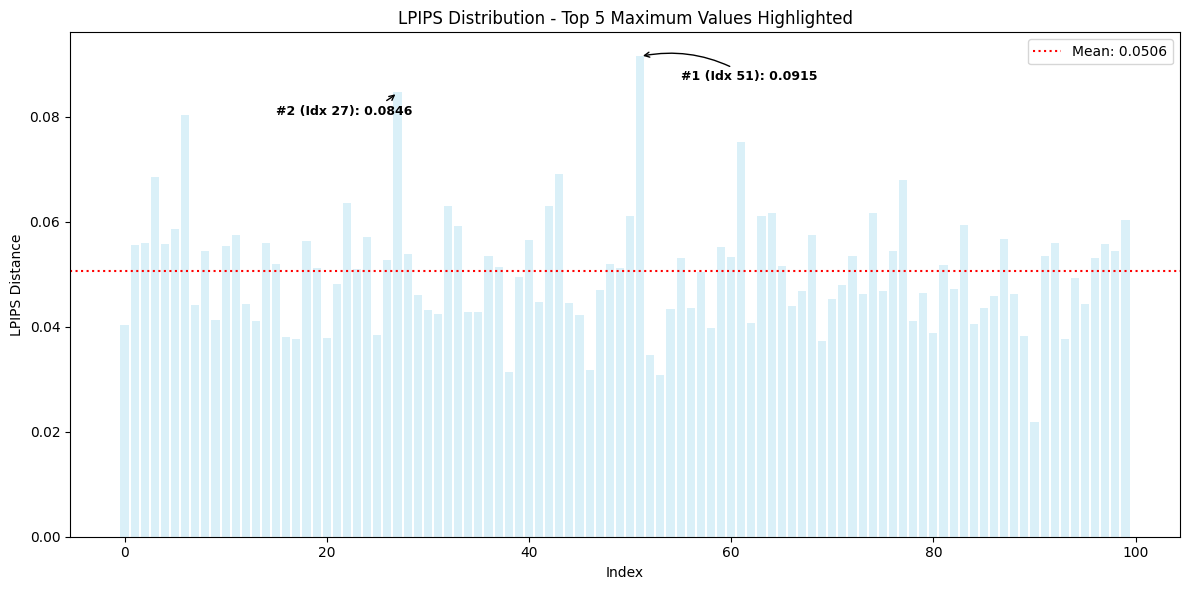

In [39]:
plot_distribution(minimum_indices_iter4)

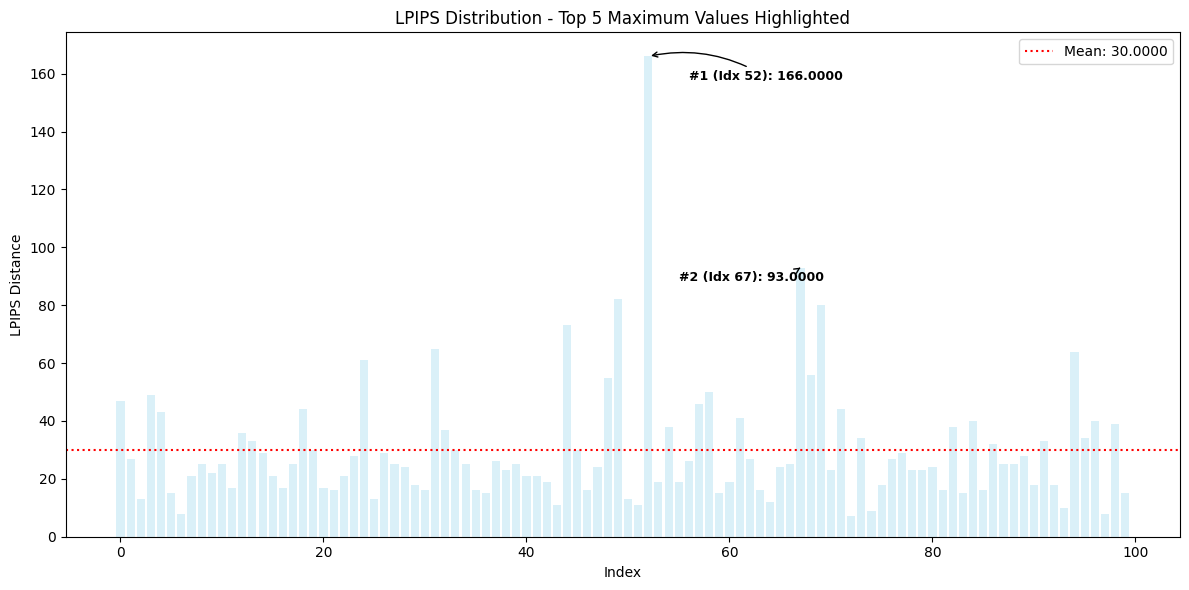

In [40]:
plot_distribution(frequency_distribution_iter4)

tensor([[ 49.,  82.],
        [ 67.,  93.],
        [ 52., 166.]])


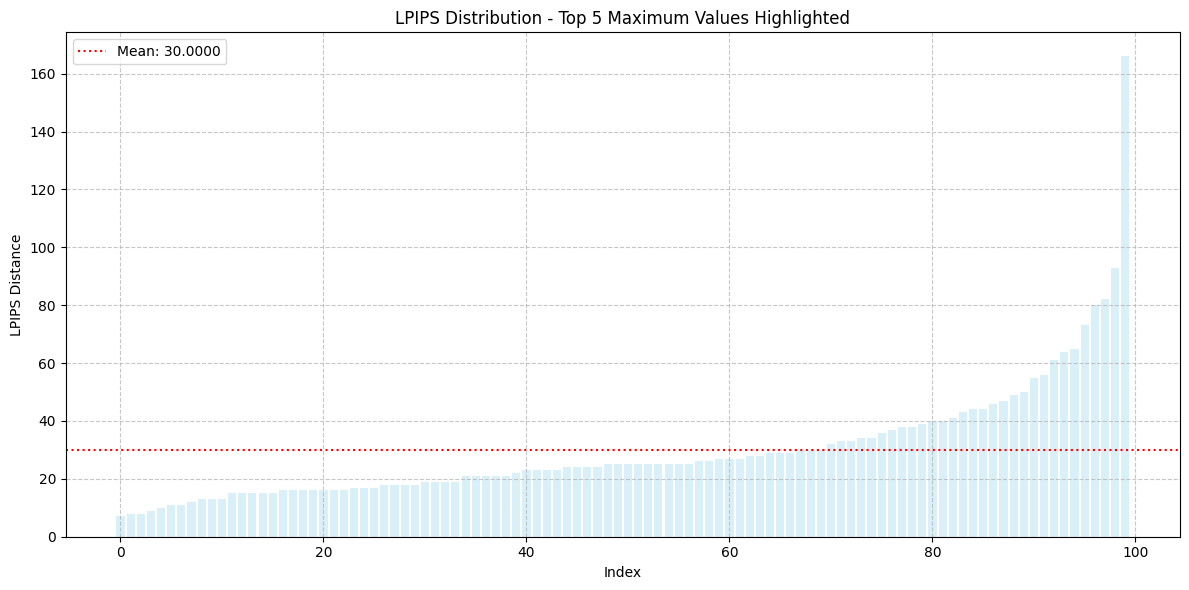

In [41]:
frequency_index_iter4=torch.argsort(frequency_distribution_iter4[:,1])
sorted_frequency_distribution_iter4=frequency_distribution_iter4[frequency_index_iter4]
print(sorted_frequency_distribution_iter4[-3:])
plot_distribution(sorted_frequency_distribution_iter4,k=0,grid=True)

In [42]:
sorted_frequency_distribution_iter4

tensor([[ 72.,   7.],
        [ 97.,   8.],
        [  6.,   8.],
        [ 74.,   9.],
        [ 93.,  10.],
        [ 51.,  11.],
        [ 43.,  11.],
        [ 64.,  12.],
        [  2.,  13.],
        [ 50.,  13.],
        [ 25.,  13.],
        [ 99.,  15.],
        [ 83.,  15.],
        [ 59.,  15.],
        [ 36.,  15.],
        [  5.,  15.],
        [ 46.,  16.],
        [ 35.,  16.],
        [ 63.,  16.],
        [ 30.,  16.],
        [ 21.,  16.],
        [ 81.,  16.],
        [ 85.,  16.],
        [ 20.,  17.],
        [ 11.,  17.],
        [ 16.,  17.],
        [ 92.,  18.],
        [ 75.,  18.],
        [ 90.,  18.],
        [ 29.,  18.],
        [ 53.,  19.],
        [ 55.,  19.],
        [ 60.,  19.],
        [ 42.,  19.],
        [ 22.,  21.],
        [ 40.,  21.],
        [ 41.,  21.],
        [  7.,  21.],
        [ 15.,  21.],
        [  9.,  22.],
        [ 38.,  23.],
        [ 70.,  23.],
        [ 78.,  23.],
        [ 79.,  23.],
        [ 65.,  24.],
        [ 

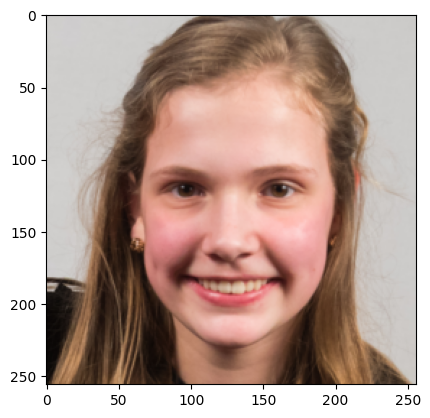

In [43]:
plt.imshow(image(original_images[72]))

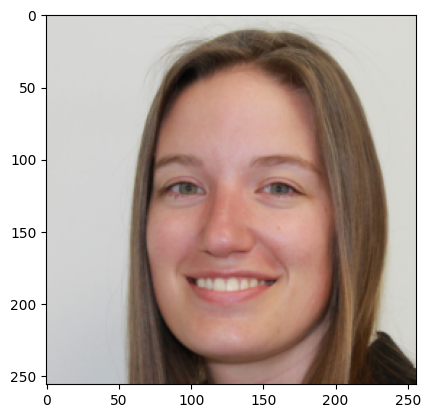

In [44]:
plt.imshow(image(original_images[52]))

In [45]:
torch.sum(sorted_frequency_distribution_iter4[:,1][-27:])

tensor(1495.)

### ANALYSIS OF FLOW BASED MODELS FOR training set of 100 CORGI IMAGES ###

#### ITERATION 1 ####

In [47]:

original_images=torch.load('/home/saurabhg/scratch/FLOW_BASED_MODELS/corgi_dataset/flow_outputs/icfm/image_tensor/original_image_tensor.pt',map_location=torch.device('cpu'))
generated_images_iter1=torch.load(f'/home/saurabhg/scratch/FLOW_BASED_MODELS/corgi_dataset/flow_outputs/icfm/image_tensor/generated_images_1000_iteration1_python_inference_scipt.pt')
minimum_indices_iter1=torch.load('/home/saurabhg/scratch/FLOW_BASED_MODELS/corgi_dataset/flow_outputs/icfm/distances/iteration1/lpips_minimum_indices.pt')
frequency_distribution_iter1=torch.load('/home/saurabhg/scratch/FLOW_BASED_MODELS/corgi_dataset/flow_outputs/icfm/distances/iteration1/frequency_distribution.pt')

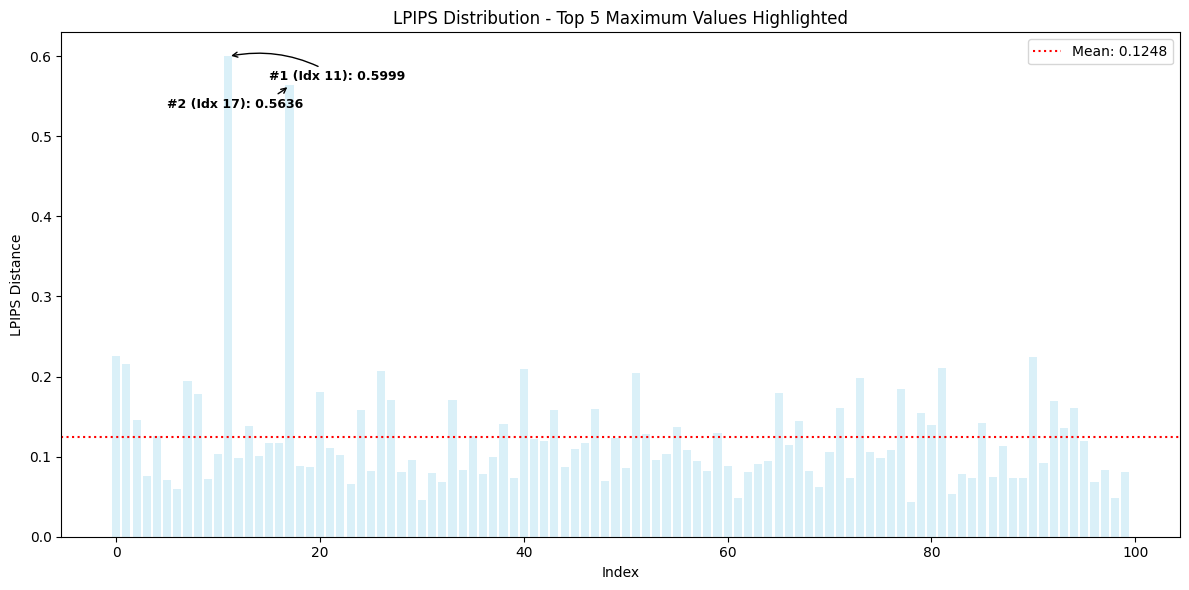

In [48]:
plot_distribution(minimum_indices_iter1)

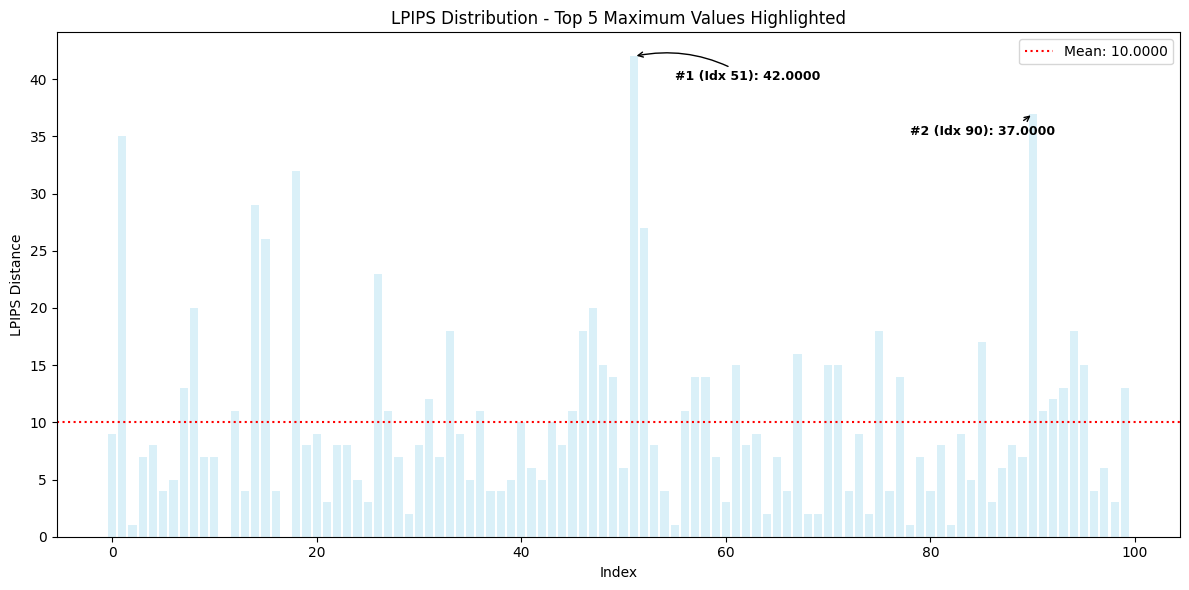

In [49]:
plot_distribution(frequency_distribution_iter1)

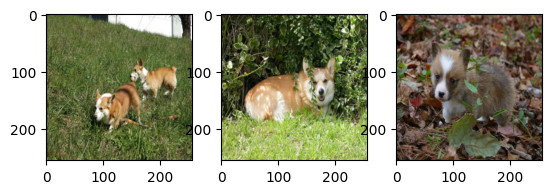

In [50]:
fig,ax=plt.subplots(1,3)

ax[0].imshow(image(original_images[51]))
ax[1].imshow(image(original_images[90]))
ax[2].imshow(image(original_images[1]))
plt.show()

tensor([[ 1., 35.],
        [90., 37.],
        [51., 42.]])


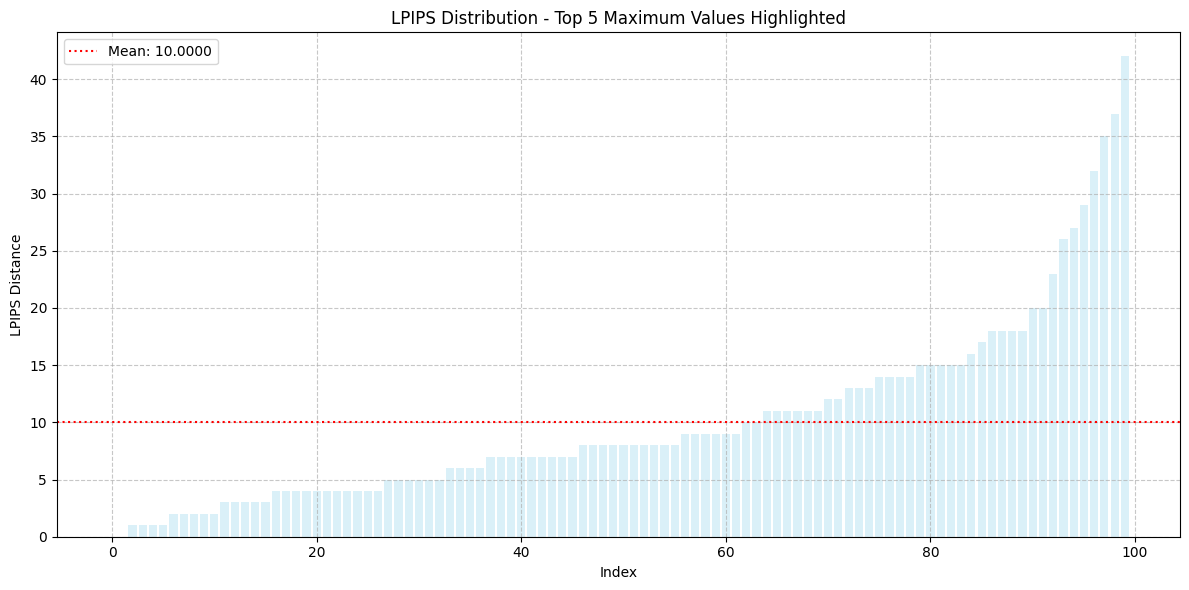

In [51]:
frequency_index_iter1=torch.argsort(frequency_distribution_iter1[:,1])
sorted_frequency_distribution_iter1=frequency_distribution_iter1[frequency_index_iter1]
print(sorted_frequency_distribution_iter1[-3:])
plot_distribution(sorted_frequency_distribution_iter1,k=0,grid=True)

In [52]:
print(sorted_frequency_distribution_iter1[:3,:])

tensor([[17.,  0.],
        [11.,  0.],
        [ 2.,  1.]])


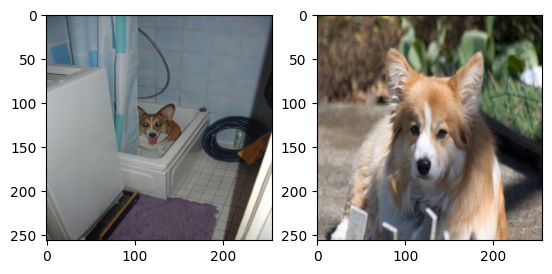

In [53]:
fig,ax=plt.subplots(1,2)

ax[0].imshow(image(original_images[17]))
ax[1].imshow(image(original_images[11]))
plt.show()

In [54]:
torch.sum(sorted_frequency_distribution_iter1[:,1][-23:])

tensor(499.)

23 modes make for 50% mode generation

### Iteration 2 ##

In [55]:
generated_images_iter2=torch.load(f'/home/saurabhg/scratch/FLOW_BASED_MODELS/corgi_dataset/flow_outputs/icfm/image_tensor/generated_images_1000_iteration2_python_inference_scipt.pt')
minimum_indices_iter2=torch.load('/home/saurabhg/scratch/FLOW_BASED_MODELS/corgi_dataset/flow_outputs/icfm/distances/iteration2/lpips_minimum_indices.pt')
frequency_distribution_iter2=torch.load('/home/saurabhg/scratch/FLOW_BASED_MODELS/corgi_dataset/flow_outputs/icfm/distances/iteration2/frequency_distribution.pt')

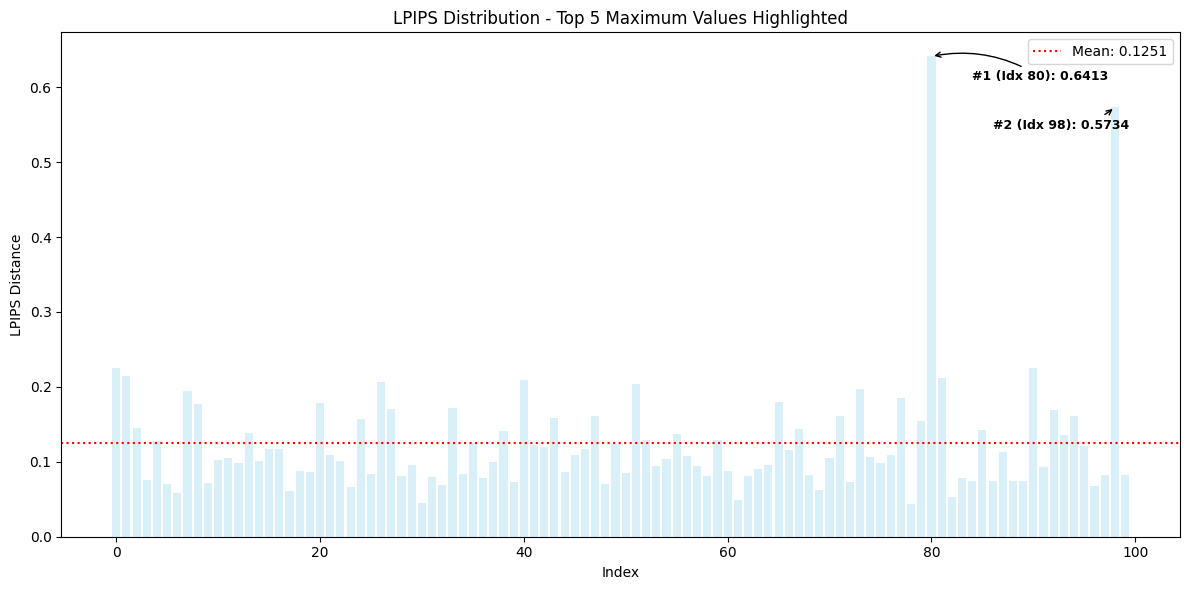

In [56]:
plot_distribution(minimum_indices_iter2)

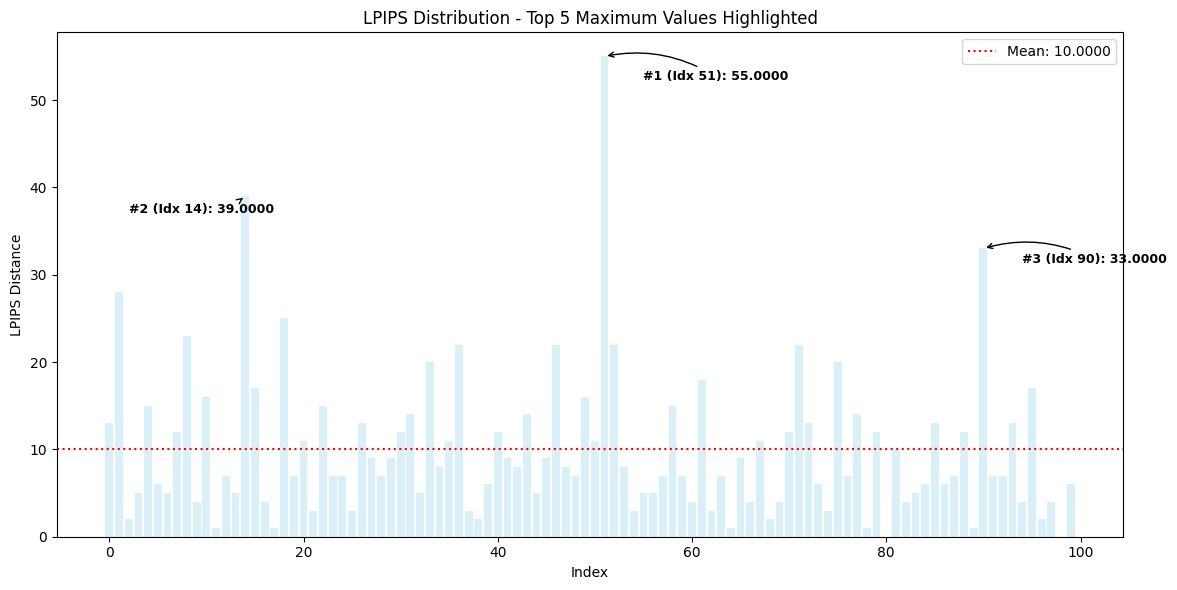

In [57]:
plot_distribution(frequency_distribution_iter2,k=3)

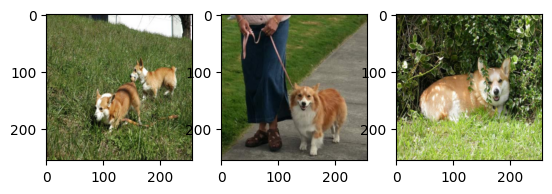

In [58]:
fig,ax=plt.subplots(1,3)

ax[0].imshow(image(original_images[51]))
ax[1].imshow(image(original_images[14]))
ax[2].imshow(image(original_images[90]))
plt.show()

tensor([[90., 33.],
        [14., 39.],
        [51., 55.]])


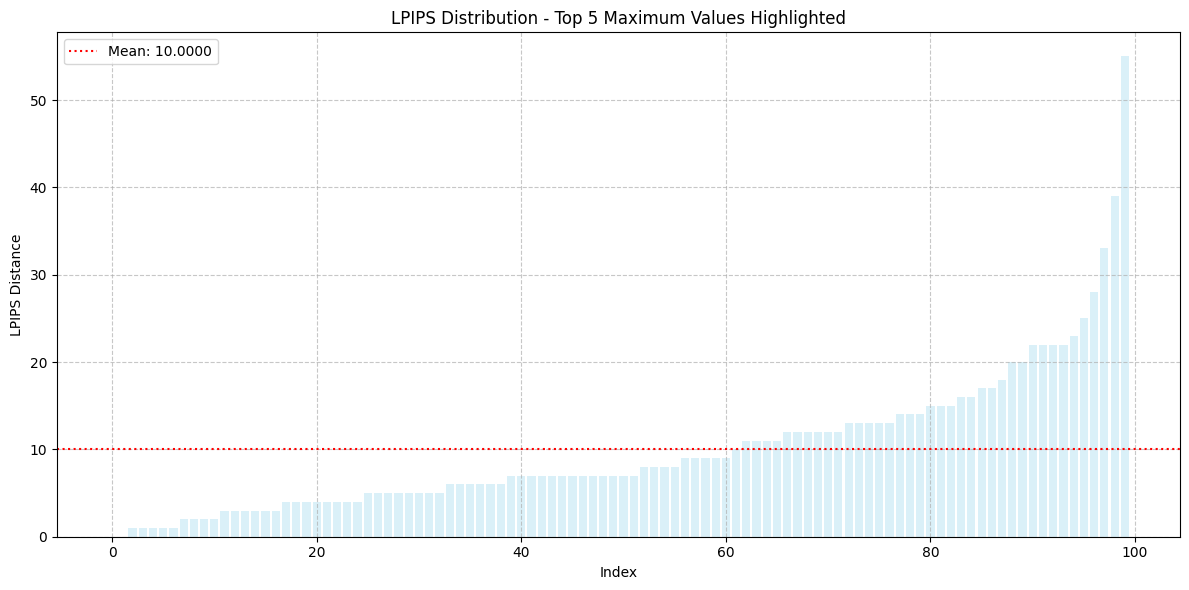

In [59]:
frequency_index_iter2=torch.argsort(frequency_distribution_iter2[:,1])
sorted_frequency_distribution_iter2=frequency_distribution_iter2[frequency_index_iter2]
print(sorted_frequency_distribution_iter2[-3:])
plot_distribution(sorted_frequency_distribution_iter2,k=0,grid=True)

In [60]:
print(sorted_frequency_distribution_iter2[:3,:])

tensor([[80.,  0.],
        [98.,  0.],
        [89.,  1.]])


2modes are dropped and top 23 modes makes up for the 50 % generation

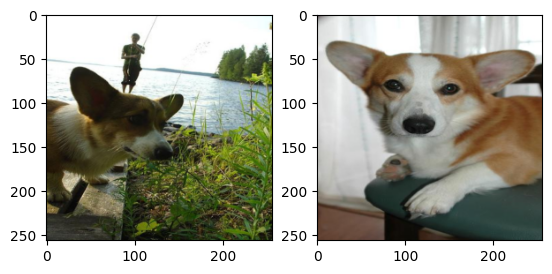

In [61]:
fig,ax=plt.subplots(1,2)

ax[0].imshow(image(original_images[80]))
ax[1].imshow(image(original_images[98]))
plt.show()

In [62]:
torch.sum(sorted_frequency_distribution_iter2[:,1][-23:])

tensor(502.)

##### For 3000 generated images ######

In [63]:
f1=torch.load('/home/saurabhg/scratch/FLOW_BASED_MODELS/corgi_dataset/flow_outputs/icfm/distances/iteration3/frequency_distribution.pt')
f2=torch.load('/home/saurabhg/scratch/FLOW_BASED_MODELS/corgi_dataset/flow_outputs/icfm/distances/iteration4/frequency_distribution.pt')
f3=torch.load('/home/saurabhg/scratch/FLOW_BASED_MODELS/corgi_dataset/flow_outputs/icfm/distances/iteration5/frequency_distribution.pt')

In [64]:
f=torch.zeros_like(f1)

f[:,0]=f1[:,0]
f[:,1]=f1[:,1]+f2[:,1]+f3[:,1]


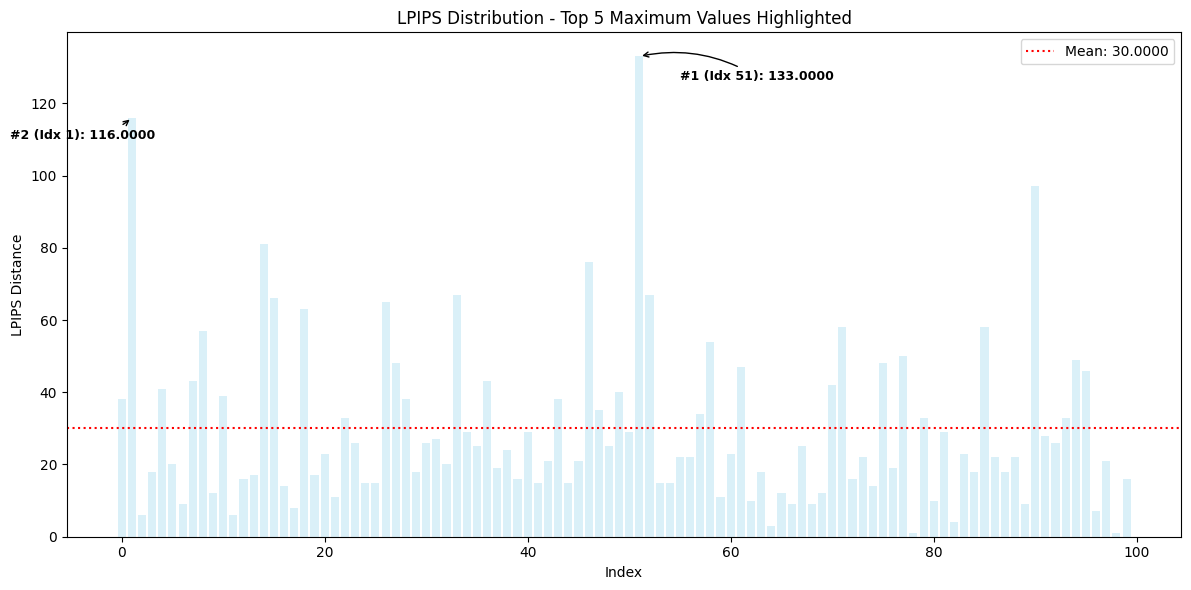

In [65]:
plot_distribution(f)

tensor([[ 90.,  97.],
        [  1., 116.],
        [ 51., 133.]])


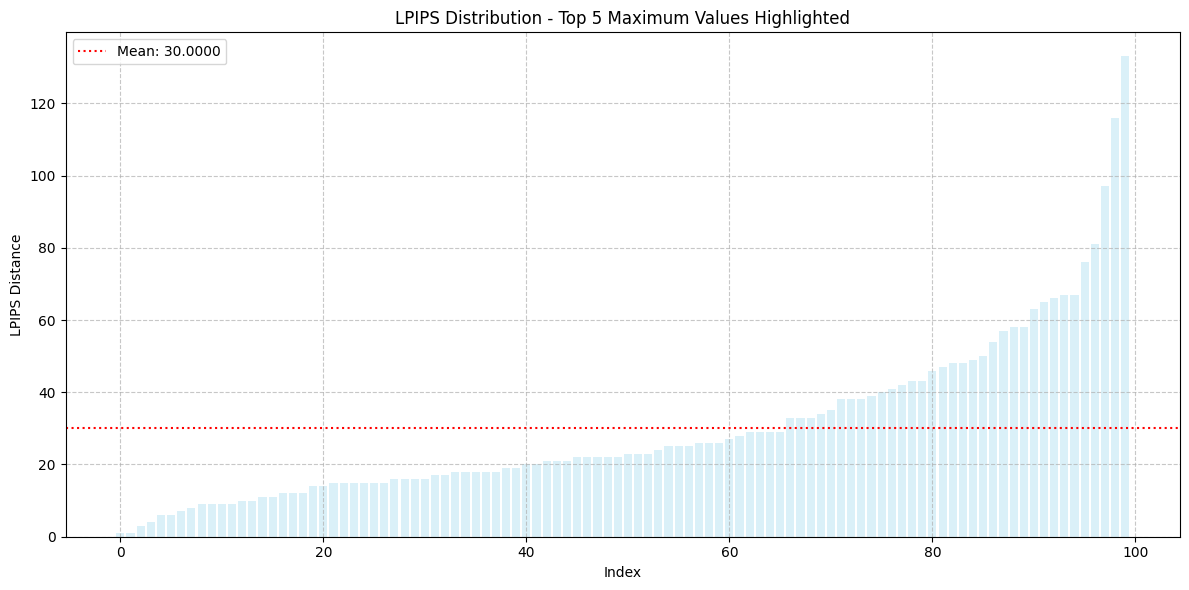

In [66]:
frequency_index_iter3=torch.argsort(f[:,1])
sorted_frequency_distribution_iter3=f[frequency_index_iter3]
print(sorted_frequency_distribution_iter3[-3:])
plot_distribution(sorted_frequency_distribution_iter3,k=0,grid=True)

In [67]:
torch.sum(sorted_frequency_distribution_iter3[:,1][-24:])

tensor(1515.)

No modes are dropped and top 24 modes makes up for 50 % of genereation for batch of 3000 generated images

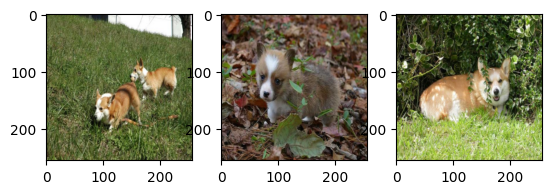

In [68]:
fig,ax=plt.subplots(1,3)

ax[0].imshow(image(original_images[51]))
ax[1].imshow(image(original_images[1]))
ax[2].imshow(image(original_images[90]))
plt.show()